# Adult Census Income — Segmentation et classification du revenu
Projet de data mining réalisé en groupe. Démarche : **CRISP-DM** adaptée.

## Sommaire
1. Business Understanding
2. Data Understanding
3. Data Exploration
4. Data Preparation
5. Segmentation
6. Classification
7. Évaluation et interprétation des résultats
8. Fichier final : données nettoyées et préparées

# 1. Business Understanding
## 1.1 Contexte
Le jeu de données *Adult Census Income* (UCI) provient du recensement américain de 1994. Il décrit des personnes (âge, éducation, profession, situation familiale, heures de travail, gains en capital…) et indique si leur revenu annuel dépasse 50 000 $.

## 1.2 Objectifs métier
- Comprendre quels facteurs socio-démographiques sont associés à un revenu élevé.
- Regrouper les individus en profils homogènes (segmentation non supervisée).
- Prédire la catégorie de revenu (classification supervisée) et mesurer la fiabilité de cette prédiction.

## 1.3 Problématiques

- Segmentation : identifier des profils similaires selon l'âge,
  le niveau d'études et les heures de travail hebdomadaires.
- Classification : prédire la catégorie de revenu <=50K ou >50K.

## 1.4 Critères de succès
- Segmentation : groupes interprétables, avec un score de silhouette comparé pour plusieurs nombres de clusters.
- Classification : la cible étant déséquilibrée (≈ 76 % de <=50K), l'accuracy seule est insuffisante ; on suit aussi le F1 et le rappel de la classe >50K, ainsi que l'AUC.
- Livrable : un fichier de données nettoyées et préparées (chapitre 8).

# 2. Data Understanding
## 2.1 Imports et chargement

**Objectif de l'EDA**
Objectif : comprendre les données **avant** de les modifier. Place `adult.data` et `adult.test` dans le même dossier que ce notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Les fichiers adult.data et adult.test doivent être dans le même dossier que le notebook
cols = ["age","workclass","fnlwgt","education","education-num","marital-status","occupation",
        "relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country","income"]
train = pd.read_csv("adult/adult.data", names=cols, skipinitialspace=True)
test  = pd.read_csv("adult/adult.test", names=cols, skipinitialspace=True, skiprows=1)  # 1ère ligne = commentaire
df = pd.concat([train, test], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2.2 Caractéristiques principales du dataset

In [3]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print("Numériques  :", num_cols)
print("Catégorielles :", cat_cols)
print("Doublons :", df.duplicated().sum())

Numériques  : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Catégorielles : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Doublons : 29


In [5]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [6]:
display(df.describe(exclude="number").T)


,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,4,<=50K,24720


**Interprétation :** Le dataset (train + test) contient 48 842 lignes et 15 variables : 6 numériques (age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week) et 9 catégorielles (dont la cible income). On trouve 29 doublons. Les valeurs manquantes sont codées `?`, donc invisibles pour `isna()`.

# 3. Data Exploration
## 3.1 Distributions des variables
### 3.1.1 Cible (income)

Modalités originales :
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Modalités normalisées :
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Proportions :
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


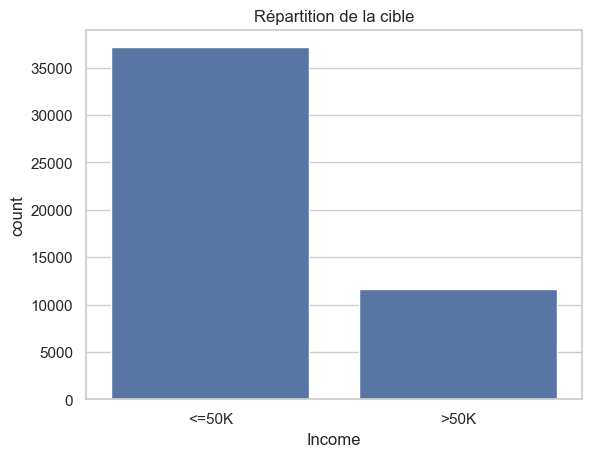

In [7]:
income_clean = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print("Modalités originales :")
print(df["income"].value_counts())

print("\nModalités normalisées :")
print(income_clean.value_counts())

print("\nProportions :")
print((income_clean.value_counts(normalize=True) * 100).round(2))

sns.countplot(
    x=income_clean,
    order=["<=50K", ">50K"]
)
plt.title("Répartition de la cible")
plt.xlabel("Income")
plt.show()


**Interprétation :** Après normalisation, 76,1 % des personnes gagnent <=50K contre 23,9 % pour >50K. Les classes sont déséquilibrées : l'accuracy seule serait trompeuse (prédire toujours <=50K donne déjà 76 %), on utilisera F1, recall, AUC et class_weight ou SMOTE.

### 3.1.2 Variables numériques

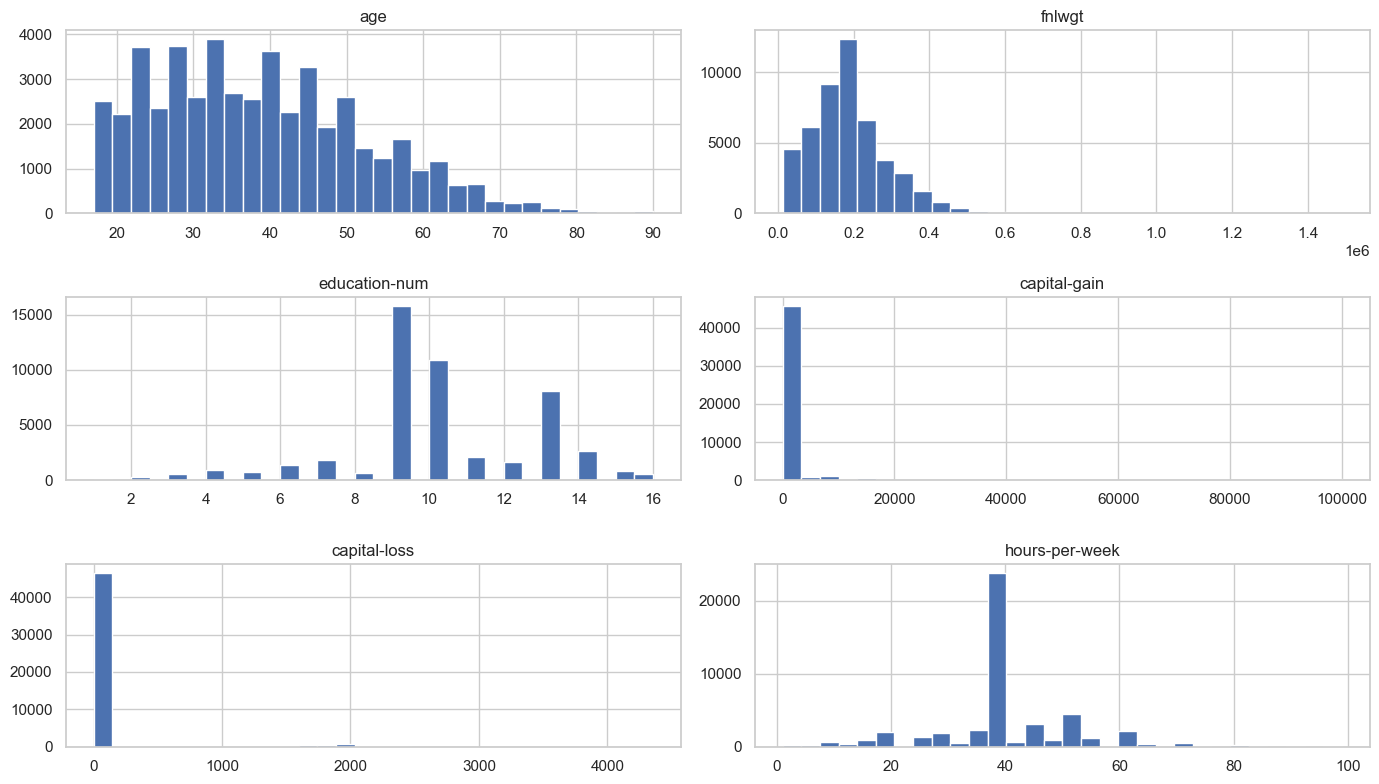

In [8]:
df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

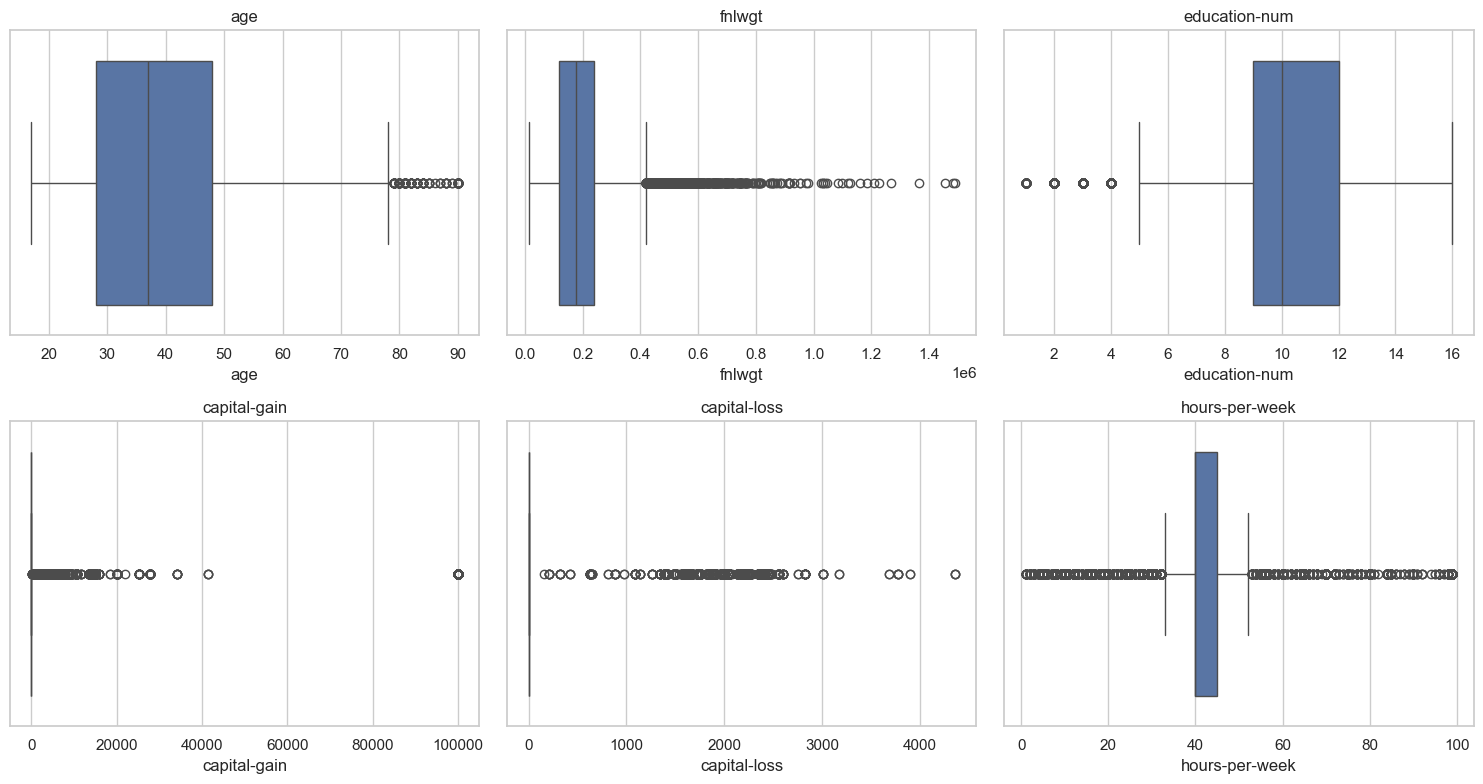

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [10]:
# Asymétrie et part de zéros
print(df[num_cols].skew().round(2))
print("\nPart de zéros :")
for c in ["capital-gain", "capital-loss"]:
    print(c, ":", round((df[c] == 0).mean() * 100, 1), "%")

age                0.56
fnlwgt             1.44
education-num     -0.32
capital-gain      11.89
capital-loss       4.57
hours-per-week     0.24
dtype: float64

Part de zéros :
capital-gain : 91.7 %
capital-loss : 95.3 %


**Interprétation :** capital-gain vaut 0 pour 91,7 % des personnes et capital-loss pour 95,3 %. Leur asymétrie est très forte (skew de 11,9 et 4,6) => transformation log1p ou variable binaire en préparation. age (0,56) et hours-per-week (0,24) sont peu asymétriques. fnlwgt (skew 1,44) est un poids d'échantillonnage, peu informatif.

### 3.1.3 Variables catégorielles

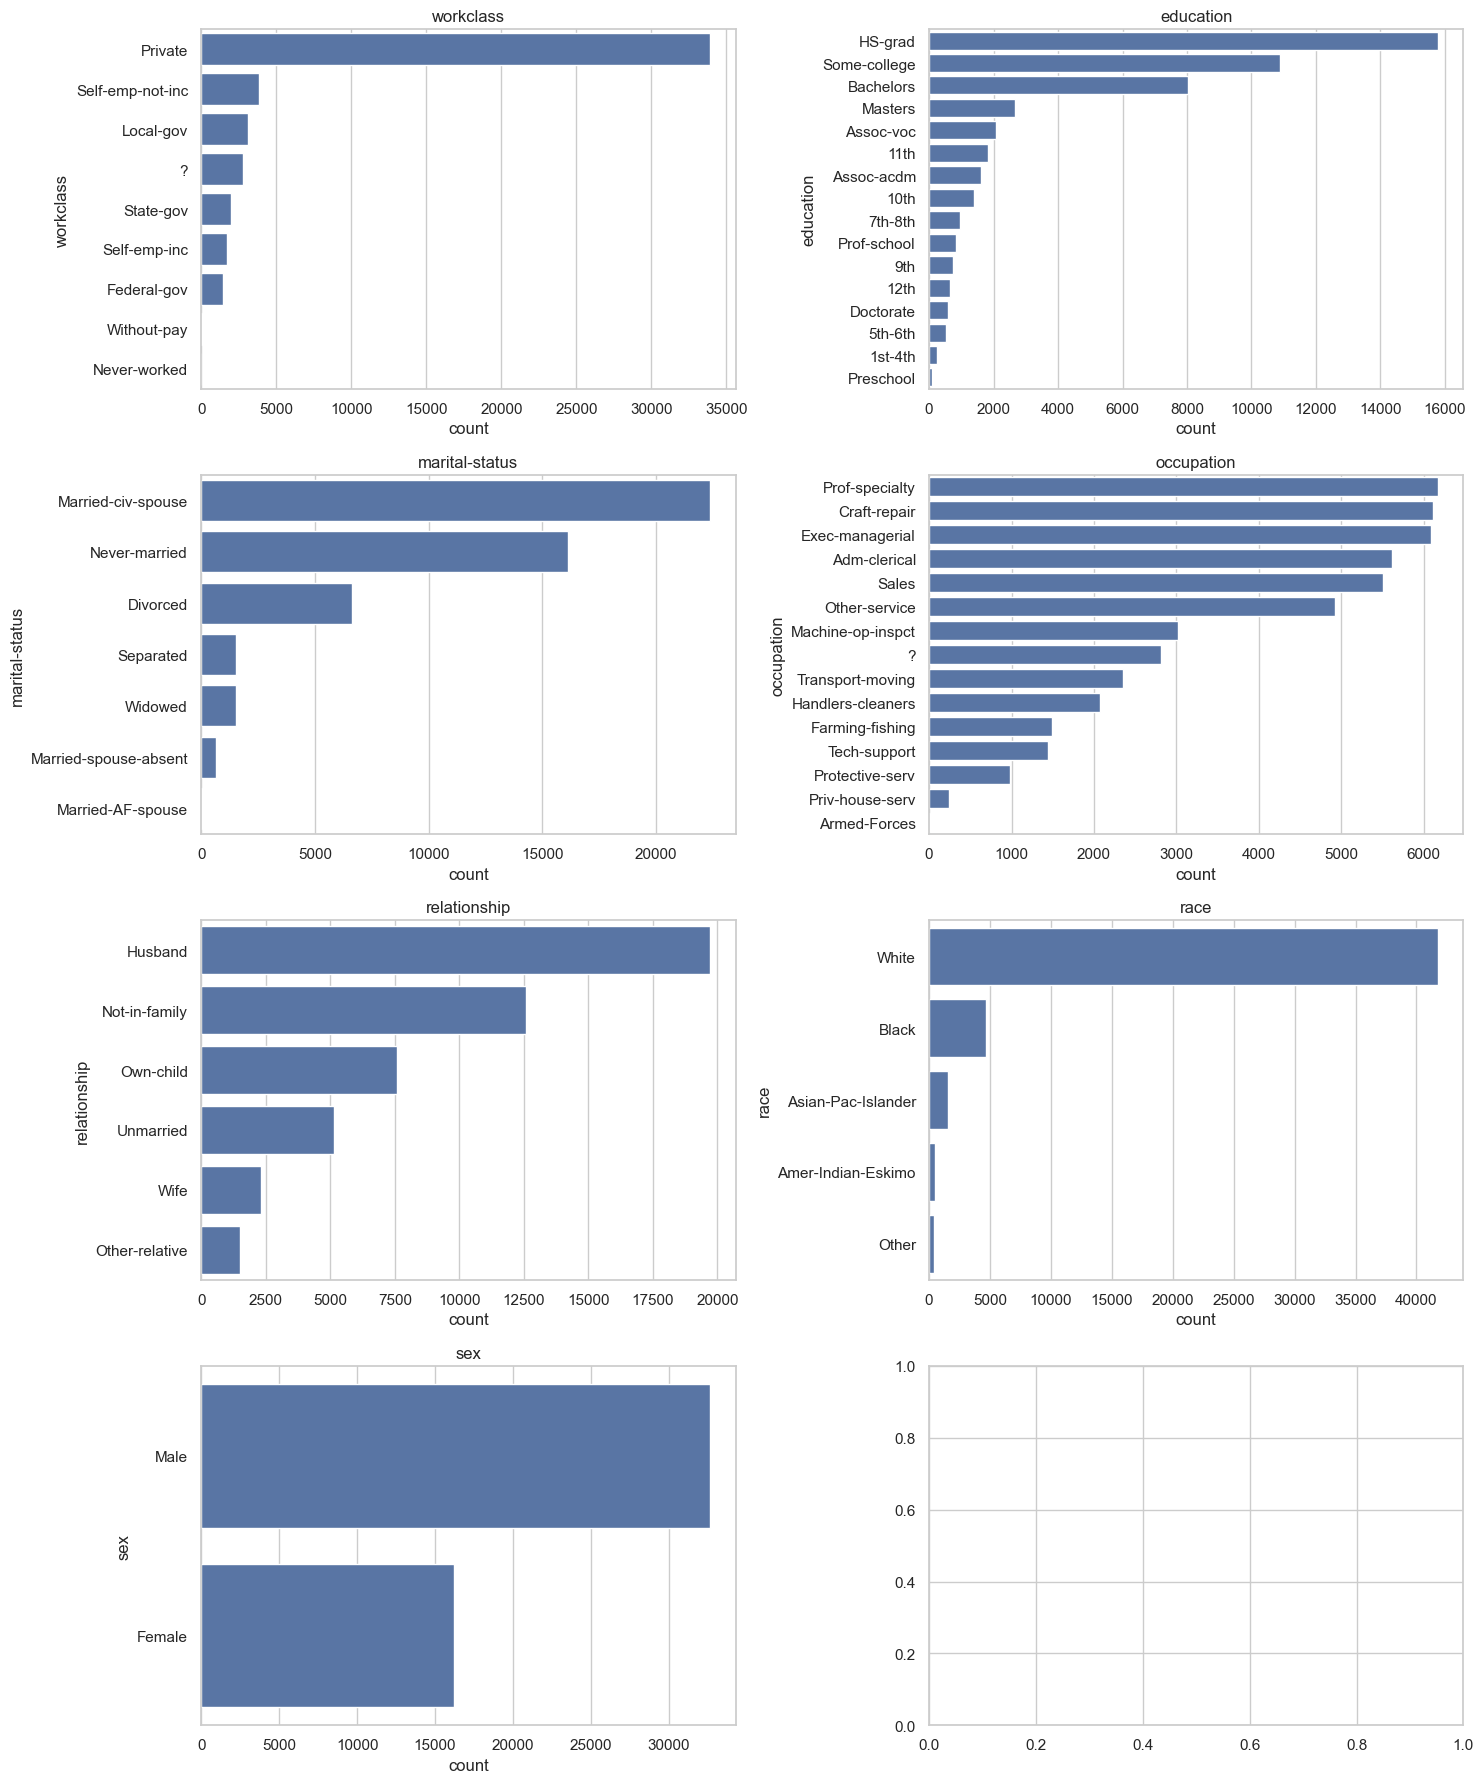

In [11]:
cat_plot = [
    c for c in cat_cols
    if c not in ["income", "native-country"]
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))

for ax, col in zip(axes.ravel(), cat_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [12]:
# native-country : très déséquilibré
print(
    df["native-country"]
    .value_counts(normalize=True)
    .head(10)
    .round(4)
)


native-country
United-States    0.8974
Mexico           0.0195
?                0.0175
Philippines      0.0060
Germany          0.0042
Puerto-Rico      0.0038
Canada           0.0037
El-Salvador      0.0032
India            0.0031
Cuba             0.0028
Name: proportion, dtype: float64


**Interprétation :** native-country est dominé par United-States (89,7 %), les autres pays sont très minoritaires => regroupement US / Autre pour éviter des dizaines de colonnes One-Hot quasi vides. Le secteur Private domine aussi workclass.

## 3.2 Relations entre variables
### 3.2.1 Corrélations

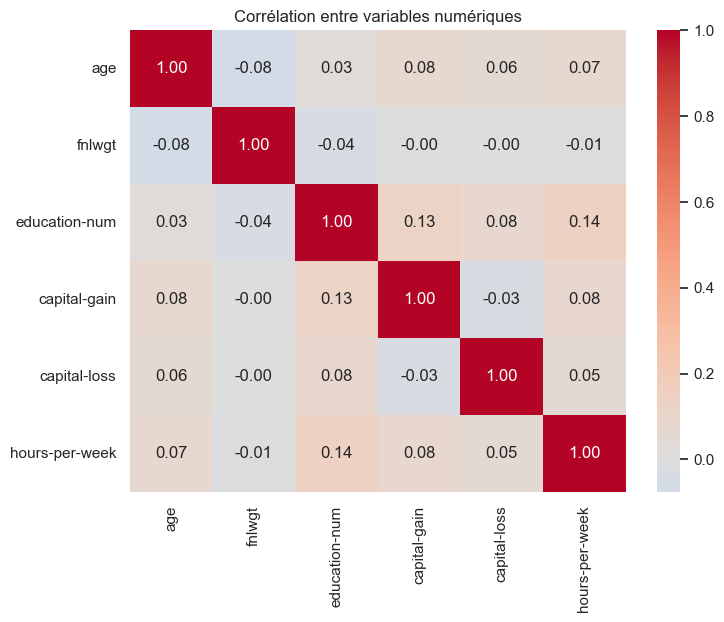

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Corrélation entre variables numériques")
plt.show()


**Interprétation :** Les corrélations entre numériques sont faibles (aucune forte hors diagonale), donc pas de multicolinéarité gênante. La plus notable : education-num et hours-per-week (0,14). fnlwgt n'est corrélée à rien.

### 3.2.2 Variables numériques vs revenu

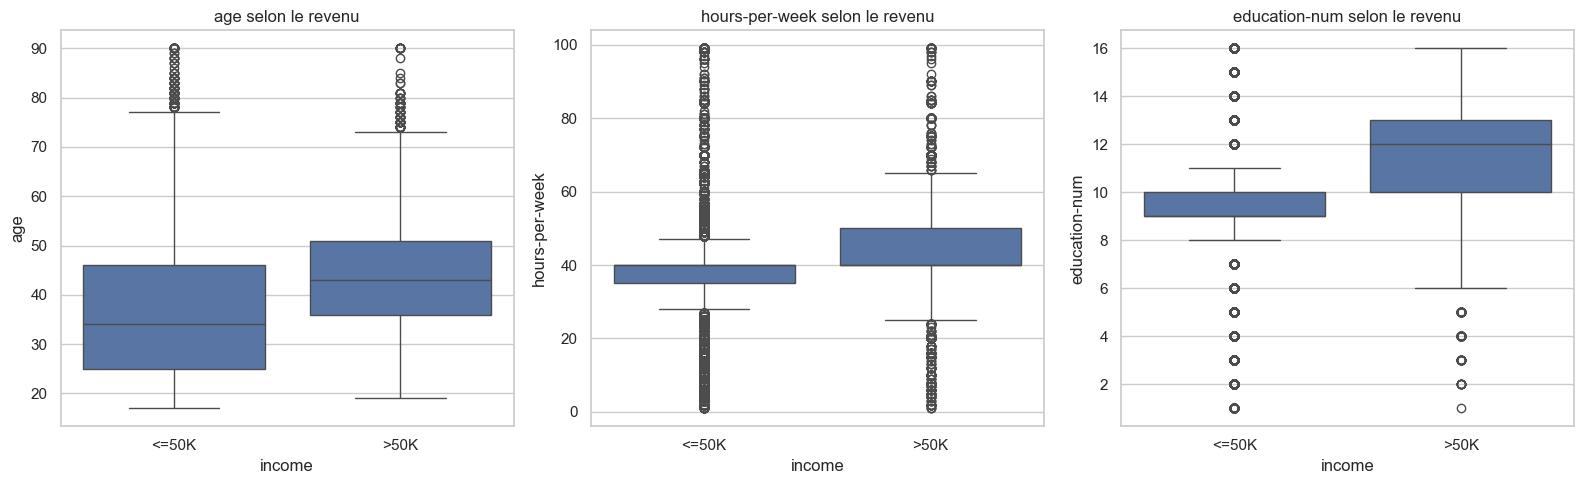

In [14]:
d = df.copy()
d["income"] = income_clean
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, ["age", "hours-per-week", "education-num"]):
    sns.boxplot(data=d, x="income", y=c, order=["<=50K", ">50K"], ax=ax)
    ax.set_title(f"{c} selon le revenu")
plt.tight_layout()
plt.show()

**Interprétation :** Les >50K sont en moyenne plus âgés (44,3 ans contre 36,9), travaillent plus (45,5 h contre 38,8 h) et sont plus diplômés (education-num 11,6 contre 9,6). Ces trois variables sont donc discriminantes pour la classification.

### 3.2.3 Variables catégorielles vs revenu

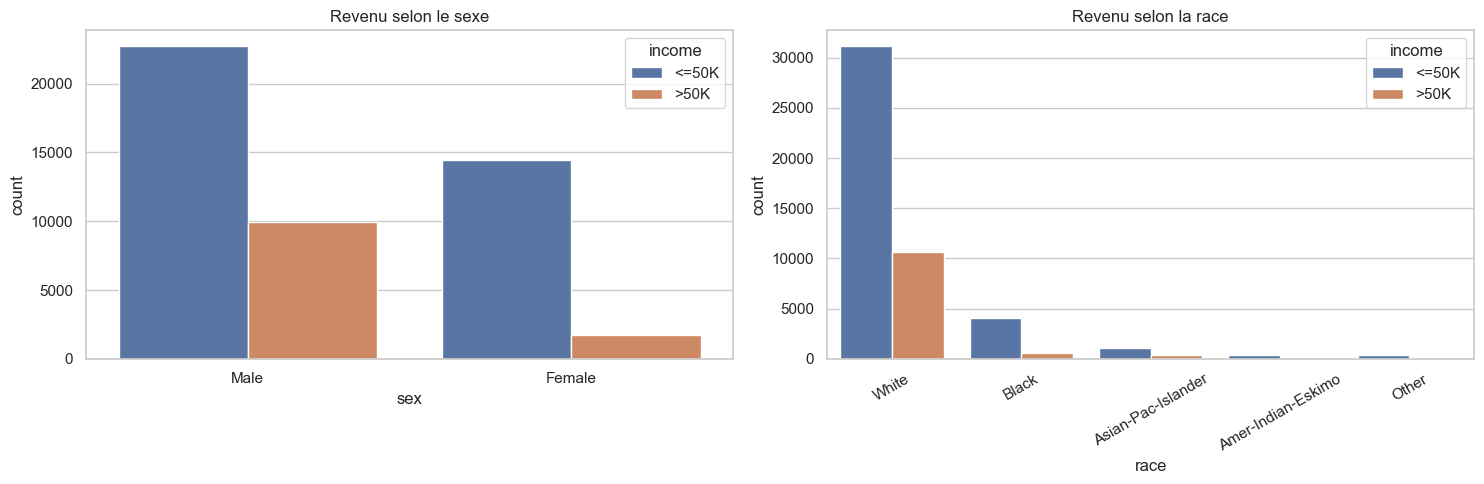

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=d, x="sex", hue="income", hue_order=["<=50K", ">50K"], ax=axes[0])
axes[0].set_title("Revenu selon le sexe")
sns.countplot(data=d, x="race", hue="income", hue_order=["<=50K", ">50K"], ax=axes[1])
axes[1].set_title("Revenu selon la race")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

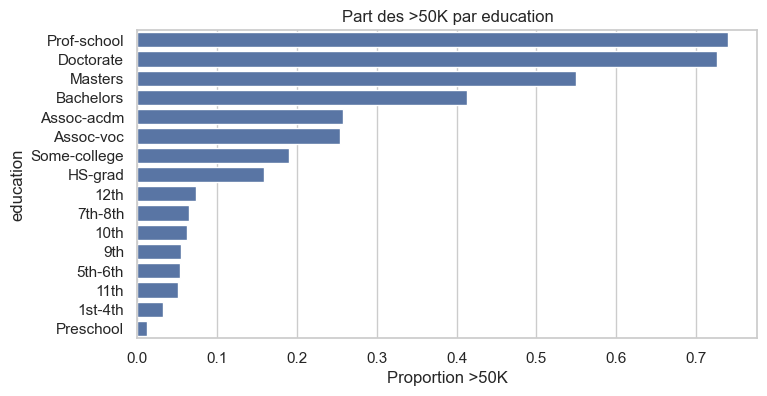

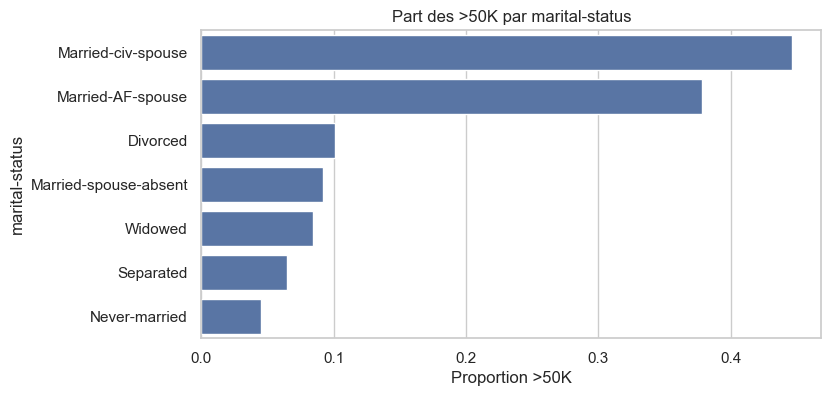

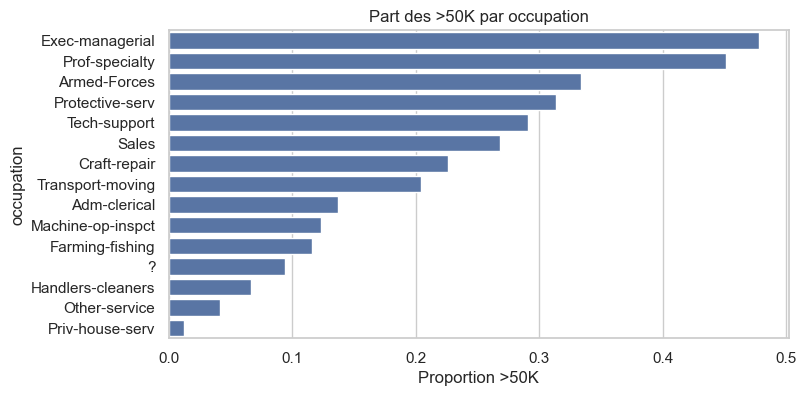

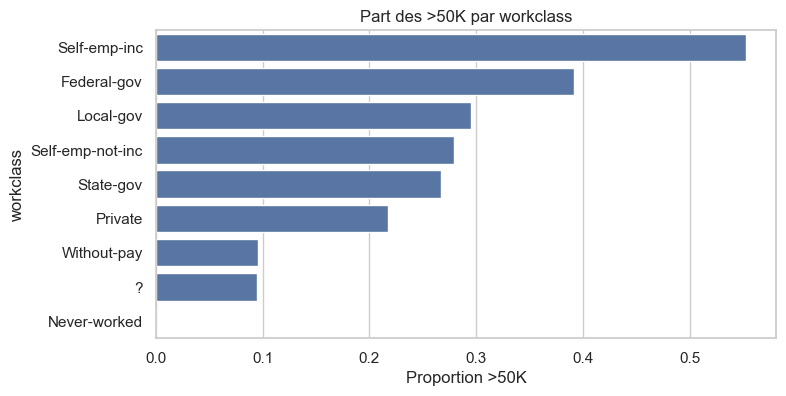

In [16]:
# Taux de revenu >50K par modalité
for c in ["education", "marital-status", "occupation", "workclass"]:
    rate = (d.assign(high=(d["income"] == ">50K")).groupby(c)["high"].mean()
              .sort_values(ascending=False))
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.values, y=rate.index)
    plt.title(f"Part des >50K par {c}")
    plt.xlabel("Proportion >50K")
    plt.show()

**Interprétation :** 30,4 % des hommes gagnent >50K contre 10,9 % des femmes. Les personnes mariées (Married-civ-spouse : 44,6 %) sont bien au-dessus des autres statuts (6 à 10 %). Le taux monte avec le diplôme : Prof-school 74 %, Doctorate 73 %, Masters 55 %, Bachelors 41 %. Les Self-emp-inc (55 %) et Federal-gov (39 %) dominent côté workclass. Attention : sexe et statut marital sont liés (biais possible à discuter).

## 3.3 Détection des anomalies
### 3.3.1 Valeurs manquantes

In [17]:
# Les manquants peuvent être NaN ou "?" selon la méthode de chargement
missing = df.isna().sum() + (df.astype(str).apply(lambda s: s.str.strip() == "?")).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print((missing / len(df) * 100).round(2).astype(str) + " %")

occupation        2809
workclass         2799
native-country     857
dtype: int64
occupation        5.75 %
workclass         5.73 %
native-country    1.75 %
dtype: object


**Interprétation :** 2 799 manquants dans workclass (5,7 %), 2 809 dans occupation (5,8 %) et 857 dans native-country (1,8 %). Ce sont des variables catégorielles avec peu de manquants, souvent sur les mêmes lignes => imputation par le mode ou catégorie Unknown en préparation.

### 3.3.2 Outliers

In [18]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    i = q3 - q1
    return ((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum()

for c in num_cols:
    print(f"{c:15s} outliers IQR : {iqr_outliers(df[c])}")

print("\ncapital-gain = 99999 :", (df["capital-gain"] == 99999).sum())
print("hours-per-week > 80  :", (df["hours-per-week"] > 80).sum())
print("hours-per-week < 10  :", (df["hours-per-week"] < 10).sum())
print("age > 85             :", (df["age"] > 85).sum())

age             outliers IQR : 216
fnlwgt          outliers IQR : 1453
education-num   outliers IQR : 1794
capital-gain    outliers IQR : 4035
capital-loss    outliers IQR : 2282
hours-per-week  outliers IQR : 13496

capital-gain = 99999 : 244
hours-per-week > 80  : 318
hours-per-week < 10  : 700
age > 85             : 67


**Interprétation :** 244 personnes ont capital-gain = 99999 : c'est un code de plafonnement (valeur tronquée), à ne pas supprimer aveuglément mais à traiter avec log ou winsorisation. On compte aussi 318 personnes à plus de 80 h/semaine, 700 à moins de 10 h et 67 de plus de 85 ans : rares mais plausibles, donc winsorisation plutôt que suppression.

### 3.3.3 Doublons et incohérences

In [19]:
print("Doublons :", df.duplicated().sum())
print("\nModalités de la cible :", df["income"].unique())

# education et education-num sont-elles redondantes ?
print(df.groupby("education")["education-num"].nunique().max(), "(1 = redondance parfaite)")

Doublons : 29

Modalités de la cible : ['<=50K' '>50K' '<=50K.' '>50K.']
1 (1 = redondance parfaite)


## 3.4 Synthèse des anomalies (base de la partie Préparation)
| Anomalie | Où | Action prévue |
|---|---|---|
| Valeurs manquantes | workclass, occupation, native-country | Imputation (mode / Unknown) |
| Cible avec un point | income | Normaliser puis encoder 0/1 |
| Outliers / code 99999 | capital-gain, hours-per-week | IQR ou winsorisation, log |
| Asymétrie | capital-gain, capital-loss | log1p |
| Redondance | education / education-num | Supprimer education |
| Doublons | 29 lignes | Supprimer |
| Déséquilibre de la cible | income | class_weight / SMOTE, métriques F1/AUC |

# 4. Data Preparation
Cette partie applique les transformations décidées dans la synthèse des anomalies (§ 3.4) : nettoyage, création de variables, traitement des outliers, encodage et séparation entraînement/test.

## 4.1 Nettoyage initial : cible, variables redondantes, doublons

In [20]:
df_clean = df.copy()

# 1. Normaliser la cible
df_clean["income"] = (
    df_clean["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# 2. Encoder la cible
df_clean["income"] = df_clean["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# 3. Supprimer les variables redondantes / non retenues
df_clean = df_clean.drop(
    columns=["education", "fnlwgt"],
    errors="ignore"
)

print("Shape après suppression des variables redondantes :", df_clean.shape)


Shape après suppression des variables redondantes : (48842, 13)


In [21]:
# ============================================================
# 3.2 - DETECTION DES VALEURS MANQUANTES
# ============================================================

missing = df_clean.isnull().sum()

print("Valeurs manquantes par variable :")
print(missing)

print("\nPourcentage de valeurs manquantes :")

missing_percent = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

print(missing_percent[missing_percent > 0])

Valeurs manquantes par variable :
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Pourcentage de valeurs manquantes :
Series([], dtype: float64)


In [22]:
duplicates_before = df_clean.duplicated().sum()

print("Doublons avant suppression :", duplicates_before)
print(
    "Pourcentage :",
    round(duplicates_before / len(df_clean) * 100, 2),
    "%"
)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Lignes après suppression :", len(df_clean))
print("Doublons après :", df_clean.duplicated().sum())


Doublons avant suppression : 6374
Pourcentage : 13.05 %
Lignes après suppression : 42468
Doublons après : 0


**Interprétation :** Une première version du nettoyage normalise la cible (suppression du point final de `<=50K.` / `>50K.`), l'encode en 0/1 et supprime `education` (redondante avec `education-num`) et `fnlwgt` : on passe de 15 à 13 colonnes. Aucune valeur manquante n'apparaît car les manquants sont codés `?` et non `NaN`. Cette version supprime aussi 6 374 doublons (13,05 %), mais ce chiffre vient du retrait de `fnlwgt` : des individus différents deviennent identiques sur les colonnes restantes, ce ne sont pas de vrais doublons. La cellule suivante repart de `df` : c'est cette seconde version, plus prudente, qui est conservée pour la suite.

## 4.2 Reprise du nettoyage et valeurs manquantes

In [23]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

# 3.1 Copie du dataset original
df_clean = df.copy()

print("Shape initiale :", df_clean.shape)

# ============================================================
# 3.2 DETECTION DES VALEURS MANQUANTES
# ============================================================

missing = df_clean.isnull().sum()

print("\nValeurs manquantes :")
print(missing)

print("\nPourcentage de valeurs manquantes :")

missing_percent = (
    df_clean.isnull().sum() / len(df_clean) * 100
)

print(
    missing_percent[missing_percent > 0]
)

Shape initiale : (48842, 15)

Valeurs manquantes :
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Pourcentage de valeurs manquantes :
Series([], dtype: float64)


In [24]:
# Vérification finale des valeurs manquantes

missing = df_clean.isnull().sum()

print("Valeurs manquantes par variable :")
print(missing)

print("\nNombre total de valeurs manquantes :",
      missing.sum())

Valeurs manquantes par variable :
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Nombre total de valeurs manquantes : 0


**Interprétation :** On repart de la copie complète de `df` (48 842 lignes, 15 colonnes). `isnull()` renvoie 0 manquant partout, avant comme après. Ce résultat est trompeur : les valeurs manquantes sont codées `?` (workclass : 2 799, occupation : 2 809, native-country : 856, constatées plus loin). Elles ne sont donc pas imputées par `SimpleImputer`, mais traitées comme une modalité à part entière lors de l'encodage one-hot.

## 4.3 Traitement des doublons

In [25]:
print("Nombre de doublons :", df_clean.duplicated().sum())

Nombre de doublons : 29


In [26]:
# ============================================================
# ANALYSE DES DOUBLONS
# ============================================================

print("Nombre total de lignes :", len(df_clean))
print("Nombre de doublons :", df_clean.duplicated().sum())

print("Pourcentage de doublons :",
      round(df_clean.duplicated().sum() / len(df_clean) * 100, 2),
      "%")

Nombre total de lignes : 48842
Nombre de doublons : 29
Pourcentage de doublons : 0.06 %


In [27]:
# Afficher quelques doublons
duplicates = df_clean[df_clean.duplicated(keep=False)]

print(duplicates.head(10))

      age workclass  fnlwgt     education  education-num      marital-status  \
2303   90   Private   52386  Some-college             10       Never-married   
3917   19   Private  251579  Some-college             10       Never-married   
4325   25   Private  308144     Bachelors             13       Never-married   
4767   21   Private  250051  Some-college             10       Never-married   
4881   25   Private  308144     Bachelors             13       Never-married   
4940   38   Private  207202       HS-grad              9  Married-civ-spouse   
5104   90   Private   52386  Some-college             10       Never-married   
5579   27   Private  255582       HS-grad              9       Never-married   
5805   20   Private  107658  Some-college             10       Never-married   
5842   25   Private  195994       1st-4th              2       Never-married   

             occupation   relationship                race     sex  \
2303      Other-service  Not-in-family  Asian-Pac

In [28]:
# Vérification des doublons exacts
print("Doublons exacts :", df_clean.duplicated().sum())

# Vérifier les doublons en ignorant la première occurrence
print("Doublons à supprimer :", df_clean.duplicated(keep='first').sum())

Doublons exacts : 29
Doublons à supprimer : 29


In [29]:
# Suppression des doublons exacts
df_clean = df_clean.drop_duplicates()

print("Nombre de lignes après suppression :", len(df_clean))
print("Nombre de doublons après :", df_clean.duplicated().sum())

Nombre de lignes après suppression : 48813
Nombre de doublons après : 0


**Interprétation :** Sur toutes les colonnes d'origine (y compris `fnlwgt`), on trouve 29 doublons exacts, soit 0,06 % des lignes. L'affichage des exemples confirme qu'il s'agit de lignes strictement identiques. Leur suppression est sans risque : le dataset passe à 48 813 lignes et 0 doublon.

## 4.4 Création de variables (feature engineering)

In [30]:
# Capital net : information synthétique sur le résultat du capital
df_clean["capital_net"] = (
    df_clean["capital-gain"]
    - df_clean["capital-loss"]
)

# Indicateur binaire du statut marital
df_clean["is_married"] = (
    df_clean["marital-status"]
    .isin(["Married-civ-spouse", "Married-AF-spouse"])
    .astype(int)
)

# Regroupement de l'âge en tranches
df_clean["age_bucket"] = pd.cut(
    df_clean["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"],
    include_lowest=True
)

print("Nouvelles features :")
print(["capital_net", "is_married", "age_bucket"])

print("\nRépartition de is_married :")
print(df_clean["is_married"].value_counts())

print("\nRépartition de age_bucket :")
print(df_clean["age_bucket"].value_counts().sort_index())


Nouvelles features :
['capital_net', 'is_married', 'age_bucket']

Répartition de is_married :
is_married
0    26404
1    22409
Name: count, dtype: int64

Répartition de age_bucket :
age_bucket
<25       9614
25-35    12713
35-45    11947
45-55     8292
55-65     4445
65+       1802
Name: count, dtype: int64


**Interprétation :** Trois variables sont créées : `capital_net` (gain − perte), `is_married` (1 si marié, 22 409 personnes soit 45,9 %) et `age_bucket` (6 tranches). Les tranches 25-35 ans (26,0 %) et 35-45 ans (24,5 %) sont les plus peuplées ; les 65 ans et plus ne représentent que 3,7 %. Ces variables synthétisent l'information et rendent les profils plus lisibles.

## 4.5 Traitement des outliers et suppression de colonnes

In [31]:
# ============================================================
# WINSORISATION DE HOURS-PER-WEEK
# ============================================================

lower = df_clean['hours-per-week'].quantile(0.01)
upper = df_clean['hours-per-week'].quantile(0.99)

print("Limite basse :", lower)
print("Limite haute :", upper)

df_clean['hours-per-week'] = df_clean[
    'hours-per-week'
].clip(
    lower=lower,
    upper=upper
)

print("\nAprès winsorisation :")
print(df_clean['hours-per-week'].describe())

Limite basse : 8.0
Limite haute : 80.0

Après winsorisation :
count    48813.000000
mean        40.376252
std         11.971635
min          8.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         80.000000
Name: hours-per-week, dtype: float64


In [32]:
df_clean = df_clean.drop(
    columns=['education', 'fnlwgt'],
    errors='ignore'
)

**Interprétation :** `hours-per-week` est winsorisée aux percentiles 1 % et 99 % (bornes 8 h et 80 h), ce qui conserve les lignes tout en limitant les valeurs extrêmes. La moyenne reste à 40,4 h et la médiane à 40 h. Les colonnes `education` et `fnlwgt` sont retirées : la première est redondante avec `education-num`, la seconde est un poids d'échantillonnage sans valeur prédictive directe.

## 4.6 Variables catégorielles et encodage

In [33]:
# ============================================================
# VARIABLES CATEGORIELLES
# ============================================================

cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

print("Variables catégorielles :")
print(cat_features)

Variables catégorielles :
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket']


In [34]:
# ============================================================
# 3.6 VARIABLES CATEGORIELLES
# ============================================================

for col in cat_features:
    print("\n", col)
    print(df_clean[col].value_counts(dropna=False))


 workclass
workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

 marital-status
marital-status
Married-civ-spouse       22372
Never-married            16098
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 occupation
occupation
Prof-specialty       6167
Craft-repair         6107
Exec-managerial      6084
Adm-clerical         5608
Sales                5504
Other-service        4919
Machine-op-inspct    3019
?                    2809
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1487
Tech-support         1445
Protective-serv       983
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64

 r

In [35]:
for col in cat_features:
    print(f"\n--- {col} ---")
    freq = df_clean[col].value_counts(normalize=True) * 100
    print(freq.round(2))


--- workclass ---
workclass
Private             69.41
Self-emp-not-inc     7.91
Local-gov            6.42
?                    5.73
State-gov            4.06
Self-emp-inc         3.47
Federal-gov          2.93
Without-pay          0.04
Never-worked         0.02
Name: proportion, dtype: float64

--- marital-status ---
marital-status
Married-civ-spouse       45.83
Never-married            32.98
Divorced                 13.58
Separated                 3.13
Widowed                   3.11
Married-spouse-absent     1.29
Married-AF-spouse         0.08
Name: proportion, dtype: float64

--- occupation ---
occupation
Prof-specialty       12.63
Craft-repair         12.51
Exec-managerial      12.46
Adm-clerical         11.49
Sales                11.28
Other-service        10.08
Machine-op-inspct     6.18
?                     5.75
Transport-moving      4.82
Handlers-cleaners     4.24
Farming-fishing       3.05
Tech-support          2.96
Protective-serv       2.01
Priv-house-serv       0.49
Armed-

In [36]:
OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


**Interprétation :** Huit variables catégorielles sont retenues. `workclass` est dominée par Private (69,4 %), `marital-status` par Married-civ-spouse (45,8 %). La modalité `?` reste présente (5,7 % de workclass, 5,8 % de occupation), tout comme des modalités très rares (Never-worked : 10 lignes). Le `OneHotEncoder(handle_unknown='ignore')` gère ces cas sans erreur si une modalité n'apparaît qu'au test.

## 4.7 Variables numériques

In [37]:
num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]

print("Variables numériques :")
print(num_features)

print("\nTypes :")
print(df_clean[num_features].dtypes)

Variables numériques :
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']

Types :
age               int64
education-num     int64
capital-gain      int64
capital-loss      int64
hours-per-week    int64
capital_net       int64
dtype: object


In [38]:
df_clean[num_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48813.0,38.647348,13.709005,17.0,28.0,37.0,48.0,90.0
education-num,48813.0,10.078688,2.570257,1.0,9.0,10.0,12.0,16.0
capital-gain,48813.0,1079.708705,7454.185982,0.0,0.0,0.0,0.0,99999.0
capital-loss,48813.0,87.554299,403.118605,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48813.0,40.376252,11.971635,8.0,40.0,40.0,45.0,80.0
capital_net,48813.0,992.154406,7477.731168,-4356.0,0.0,0.0,0.0,99999.0


In [39]:
print("Skewness des variables numériques :")
print(df_clean[num_features].skew().sort_values(ascending=False))

Skewness des variables numériques :
capital-gain      11.891093
capital_net       11.811381
capital-loss       4.568263
age                0.556775
hours-per-week     0.017305
education-num     -0.315007
dtype: float64


In [40]:
print(df_clean[['capital-gain', 'capital-loss', 'capital_net']].head(10))

   capital-gain  capital-loss  capital_net
0          2174             0         2174
1             0             0            0
2             0             0            0
3             0             0            0
4             0             0            0
5             0             0            0
6             0             0            0
7             0             0            0
8         14084             0        14084
9          5178             0         5178


In [41]:
print("Capital-gain unique :", df_clean['capital-gain'].nunique())
print("Capital-loss unique :", df_clean['capital-loss'].nunique())
print("Capital-net unique :", df_clean['capital_net'].nunique())

Capital-gain unique : 123
Capital-loss unique : 99
Capital-net unique : 221


In [42]:
for col in num_features:
    print(f"\n--- {col} ---")
    print("Min :", df_clean[col].min())
    print("Max :", df_clean[col].max())
    print("Q1  :", df_clean[col].quantile(0.25))
    print("Q3  :", df_clean[col].quantile(0.75))


--- age ---
Min : 17
Max : 90
Q1  : 28.0
Q3  : 48.0

--- education-num ---
Min : 1
Max : 16
Q1  : 9.0
Q3  : 12.0

--- capital-gain ---
Min : 0
Max : 99999
Q1  : 0.0
Q3  : 0.0

--- capital-loss ---
Min : 0
Max : 4356
Q1  : 0.0
Q3  : 0.0

--- hours-per-week ---
Min : 8
Max : 80
Q1  : 40.0
Q3  : 45.0

--- capital_net ---
Min : -4356
Max : 99999
Q1  : 0.0
Q3  : 0.0


In [43]:
print("hours-per-week > 80 :", (df_clean['hours-per-week'] > 80).sum())
print("hours-per-week < 10 :", (df_clean['hours-per-week'] < 10).sum())

print("\nage > 85 :", (df_clean['age'] > 85).sum())

hours-per-week > 80 : 0
hours-per-week < 10 : 700

age > 85 : 66


In [44]:
print(df_clean[['hours-per-week', 'age']].describe())

       hours-per-week           age
count    48813.000000  48813.000000
mean        40.376252     38.647348
std         11.971635     13.709005
min          8.000000     17.000000
25%         40.000000     28.000000
50%         40.000000     37.000000
75%         45.000000     48.000000
max         80.000000     90.000000


In [45]:
print("Valeurs hours-per-week les plus fréquentes :")
print(df_clean['hours-per-week'].value_counts().sort_index().tail(15))

Valeurs hours-per-week les plus fréquentes :
hours-per-week
65    355
66     23
67      6
68     16
69      1
70    437
72    107
73      4
74      3
75    105
76      4
77      9
78     13
79      1
80    528
Name: count, dtype: int64


**Interprétation :** Six variables numériques sont retenues. `capital-gain` (skew 11,9), `capital_net` (11,8) et `capital-loss` (4,6) sont très asymétriques : plus de 90 % de zéros, avec un maximum à 99 999 qui est un code de plafonnement. `age` (0,56), `hours-per-week` (0,02) et `education-num` (−0,32) sont proches d'une distribution symétrique. Après winsorisation, aucune valeur ne dépasse 80 h ; 700 personnes travaillent moins de 10 h par semaine et 66 ont plus de 85 ans. Ces cas sont plausibles (temps partiel, retraités) et sont conservés. La standardisation du pipeline limitera l'effet des échelles très différentes.

## 4.8 Contrôle des nouvelles variables et vérification finale

In [46]:
print("Colonnes de feature engineering :")
print(['capital_net', 'is_married', 'age_bucket'])

print("\n--- capital_net ---")
print(df_clean['capital_net'].describe())

print("\n--- is_married ---")
print(df_clean['is_married'].value_counts())
print(df_clean['is_married'].value_counts(normalize=True) * 100)

print("\n--- age_bucket ---")
print(df_clean['age_bucket'].value_counts().sort_index())
print(df_clean['age_bucket'].value_counts(normalize=True).sort_index() * 100)

Colonnes de feature engineering :
['capital_net', 'is_married', 'age_bucket']

--- capital_net ---
count    48813.000000
mean       992.154406
std       7477.731168
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_net, dtype: float64

--- is_married ---
is_married
0    26404
1    22409
Name: count, dtype: int64
is_married
0    54.092148
1    45.907852
Name: proportion, dtype: float64

--- age_bucket ---
age_bucket
<25       9614
25-35    12713
35-45    11947
45-55     8292
55-65     4445
65+       1802
Name: count, dtype: int64
age_bucket
<25      19.695573
25-35    26.044291
35-45    24.475037
45-55    16.987278
55-65     9.106181
65+       3.691640
Name: proportion, dtype: float64


In [47]:
print("=" * 60)
print("VÉRIFICATION FINALE DU DATASET")
print("=" * 60)

print("\n1. Dimensions :")
print(df_clean.shape)

print("\n2. Valeurs manquantes :")
print(df_clean.isnull().sum().sum())

print("\n3. Doublons :")
print(df_clean.duplicated().sum())

print("\n4. Types de données :")
print(df_clean.dtypes)

print("\n5. Distribution de la cible :")
print(df_clean['income'].value_counts())

print("\n6. Distribution de la cible (%) :")
print((df_clean['income'].value_counts(normalize=True) * 100).round(2))

VÉRIFICATION FINALE DU DATASET

1. Dimensions :
(48813, 16)

2. Valeurs manquantes :
0

3. Doublons :
4475

4. Types de données :
age                  int64
workclass           object
education-num        int64
marital-status      object
occupation          object
relationship        object
race                object
sex                 object
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country      object
income              object
capital_net          int64
is_married           int64
age_bucket        category
dtype: object

5. Distribution de la cible :
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

6. Distribution de la cible (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64


**Interprétation :** Le contrôle confirme 48 813 lignes, 16 colonnes et 0 valeur manquante. Deux points d'attention : (1) la cible `income` contient encore quatre écritures (`<=50K`, `<=50K.`, `>50K`, `>50K.`) car la normalisation de la première version a été écrasée ; elle est harmonisée plus loin dans la partie Classification (§ 6.1) et dans l'export final (§ 8) ; (2) 4 475 lignes apparaissent comme doublons une fois `fnlwgt` retiré, mais il s'agit d'individus distincts au profil identique, non supprimés ici.

## 4.9 Séparation X / y et entraînement / test

In [48]:
X = df_clean.drop(columns=['income'])
y = df_clean['income']

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

print("\nColonnes utilisées pour X :")
print(X.columns.tolist())

print("\nDistribution de y :")
print(y.value_counts())

Shape de X : (48813, 15)
Shape de y : (48813,)

Colonnes utilisées pour X :
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'capital_net', 'is_married', 'age_bucket']

Distribution de y :
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribution de y_train (%) :")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribution de y_test (%) :")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train : (39050, 15)
X_test  : (9763, 15)
y_train : (39050,)
y_test  : (9763,)

Distribution de y_train (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64

Distribution de y_test (%) :
income
<=50K     50.60
<=50K.    25.46
>50K      16.06
>50K.      7.88
Name: proportion, dtype: float64


In [50]:
num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]
cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

**Interprétation :** `X` contient 15 variables explicatives et `y` la cible. Le découpage 80/20 stratifié (`random_state=42`) donne 39 050 lignes d'entraînement et 9 763 de test, avec exactement les mêmes proportions de la cible dans les deux ensembles (50,60 % / 25,46 % / 16,06 % / 7,88 % pour les quatre écritures). La stratification est donc respectée.

## 4.10 Pipelines de prétraitement

In [51]:


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Pipeline numérique créée :")
print(num_pipeline)

Pipeline numérique créée :
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# Variables numériques
# =========================

num_features = [
    'age',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'capital_net'
]

# =========================
# Variables catégorielles
# =========================

cat_features = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_bucket'
]

# =========================
# Pipeline numérique
# =========================

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# =========================
# Pipeline catégoriel
# =========================

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# =========================
# Preprocessor
# =========================

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print("Preprocessor créé avec succès !")
print(preprocessor)

Preprocessor créé avec succès !
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week',
                                  'capital_net']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation'

In [53]:
# Vérification des colonnes
print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)

print("\nNombre de variables numériques :", len(num_features))
print("Nombre de variables catégorielles :", len(cat_features))

# Vérifier que toutes les colonnes existent
all_features = num_features + cat_features

missing_features = [
    col for col in all_features
    if col not in X_train.columns
]

print("\nColonnes manquantes :", missing_features)

Variables numériques : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net']
Variables catégorielles : ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket']

Nombre de variables numériques : 6
Nombre de variables catégorielles : 8

Colonnes manquantes : []


**Interprétation :** Le pipeline numérique impute la médiane puis standardise ; le pipeline catégoriel impute la modalité la plus fréquente puis applique le one-hot. Le `ColumnTransformer` combine les deux (6 variables numériques, 8 catégorielles, aucune colonne manquante). Ajuster ce préprocesseur uniquement sur l'entraînement évite les fuites de données vers le test.

# 5. Segmentation
## 5.1 Vérification avant modélisation

In [54]:
# Copie de travail : df_clean reste inchangé.
data_ml = df_clean.copy(deep=True)

print("DIMENSIONS")
print(data_ml.shape)

print("\nCOLONNES ET TYPES")
print(data_ml.dtypes)

print("\nVALEURS DE LA CIBLE")
print(data_ml["income"].value_counts(dropna=False))

print("\nVALEURS MANQUANTES")
print(data_ml.isna().sum())

print("\nVALEURS '?' RESTANTES")
for colonne in data_ml.select_dtypes(
    include=["object", "string", "category"]
).columns:
    nombre = (
        data_ml[colonne]
        .astype("string")
        .str.strip()
        .eq("?")
        .sum()
    )
    if nombre > 0:
        print(f"{colonne} : {nombre}")

print("\nVARIABLES POUR LA SEGMENTATION")
display(
    data_ml[
        ["age", "education-num", "hours-per-week"]
    ].describe().round(2)
)

DIMENSIONS
(48813, 16)

COLONNES ET TYPES
age                  int64
workclass           object
education-num        int64
marital-status      object
occupation          object
relationship        object
race                object
sex                 object
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country      object
income              object
capital_net          int64
is_married           int64
age_bucket        category
dtype: object

VALEURS DE LA CIBLE
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

VALEURS MANQUANTES
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
capital_net       0
is_married        0
age_bucket        0
dtype: int64

VALEURS '?' RESTANTES
workclass : 2799
o

,age,education-num,hours-per-week
count,48813.00,48813.00,48813.00
mean,38.65,10.08,40.38
std,13.71,2.57,11.97
min,17.00,1.00,8.00
25%,28.00,9.00,40.00
50%,37.00,10.00,40.00
75%,48.00,12.00,45.00
max,90.00,16.00,80.00


### Vérification avant modélisation

Nous travaillons sur une copie pour préserver les données de nos collègues.
Le tableau contient 48 813 lignes et 16 colonnes. Les trois variables
de segmentation sont numériques et sans valeurs manquantes.

Pour la classification, nous devrons harmoniser les deux classes de revenu
écrites avec ou sans point et prendre en compte les catégories « ? » restantes.

### 5.2 - Sélection et standardisation des variables

In [55]:
variables_seg = ["age", "education-num", "hours-per-week"]

X_seg = data_ml[variables_seg].copy()

scaler_seg = StandardScaler()

X_seg_scaled = pd.DataFrame(
    scaler_seg.fit_transform(X_seg),
    columns=variables_seg,
    index=X_seg.index
)

print("Dimensions :", X_seg_scaled.shape)

display(pd.DataFrame({
    "Moyenne après": X_seg_scaled.mean(),
    "Écart-type après": X_seg_scaled.std(ddof=0)
}).round(4))

Dimensions : (48813, 3)


,Moyenne après,Écart-type après
age,-0.0,1.0
education-num,-0.0,1.0
hours-per-week,-0.0,1.0


### Préparation de la segmentation

Nous retenons l'âge, le niveau d'études et les heures de travail
pour obtenir des profils simples à interpréter, sans utiliser income.

Nous appliquons StandardScaler pour mettre ces variables sur une
échelle comparable avant K-Means. Chaque variable est centrée autour
de 0 et ramenée à un écart-type de 1.

### 5.3 - Comparaison des nombres de clusters

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultats_seg = []
modeles_seg = {}

for k in range(2, 7):
    modele = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    groupes = modele.fit_predict(X_seg_scaled)

    silhouette = silhouette_score(
        X_seg_scaled,
        groupes,
        sample_size=min(3000, len(X_seg_scaled)),
        random_state=42
    )

    modeles_seg[k] = modele

    resultats_seg.append({
        "Nombre de clusters": k,
        "Inertie": modele.inertia_,
        "Silhouette estimée": silhouette
    })

scores_seg = pd.DataFrame(resultats_seg)

display(scores_seg.round(4))

,Nombre de clusters,Inertie,Silhouette estimée
0,2,111087.9167,0.2420
1,3,84574.9291,0.2871
2,4,71079.2161,0.3026
3,5,60057.9513,0.3233
4,6,51709.0544,0.3391


### Comparaison des clusters

Nous avons testé 2 à 6 groupes avec K-Means pour comparer plusieurs
segmentations plutôt que fixer arbitrairement leur nombre.

La silhouette augmente de 0,2420 à 0,3391. La solution à 6 clusters
obtient le meilleur score parmi les solutions testées, mais cela
ne prouve pas que 6 est le meilleur nombre possible.

L'inertie diminue avec le nombre de groupes : cette baisse seule
ne suffit pas pour choisir. Nous examinons donc les deux courbes
avant de retenir une solution.

### 5.4 - Choix du nombre de clusters

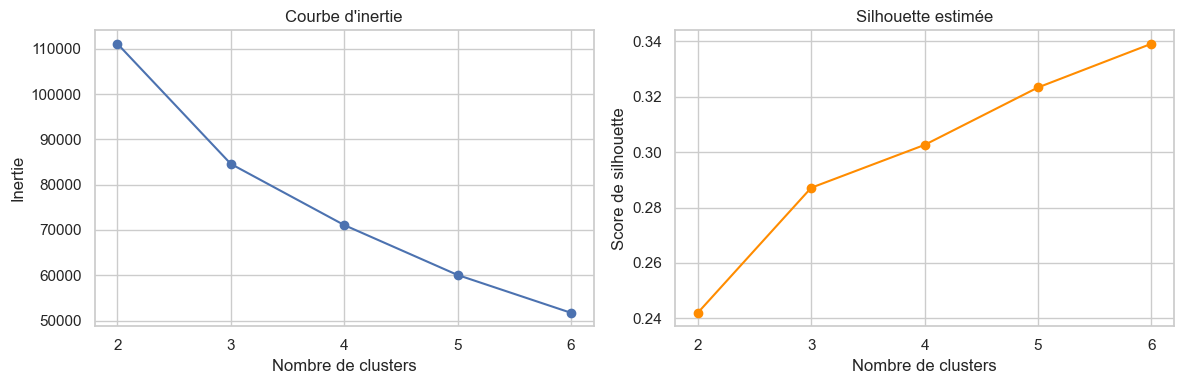

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    scores_seg["Nombre de clusters"],
    scores_seg["Inertie"],
    marker="o"
)
axes[0].set_title("Courbe d'inertie")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].set_xticks(scores_seg["Nombre de clusters"])

axes[1].plot(
    scores_seg["Nombre de clusters"],
    scores_seg["Silhouette estimée"],
    marker="o",
    color="darkorange"
)
axes[1].set_title("Silhouette estimée")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_xticks(scores_seg["Nombre de clusters"])

plt.tight_layout()
plt.show()

### Choix du nombre de clusters

Nous avons tracé les courbes pour comparer la dispersion interne
et la séparation des groupes.

L'inertie diminue sans coude nettement marqué. Nous retenons donc
provisoirement 6 clusters selon notre critère principal : la meilleure
silhouette estimée parmi les solutions testées, soit 0,3391.

Ce choix ne garantit pas un optimum absolu. Nous vérifions maintenant
les effectifs et les profils pour juger leur intérêt.

### 5.5 - Description et interprétation des profils

In [58]:
# Sélection du meilleur score parmi les solutions testées.
k_retenu = int(
    scores_seg.loc[
        scores_seg["Silhouette estimée"].idxmax(),
        "Nombre de clusters"
    ]
)

modele_seg = modeles_seg[k_retenu]

# Tableau séparé : data_ml et df_clean restent inchangés.
data_seg = data_ml.copy(deep=True)
data_seg["cluster"] = modele_seg.labels_

profils_seg = data_seg.groupby("cluster").agg(
    Effectif=("age", "size"),
    Age_moyen=("age", "mean"),
    Niveau_etudes_moyen=("education-num", "mean"),
    Heures_travail_moyennes=("hours-per-week", "mean")
)

profils_seg["Part_pct"] = (
    profils_seg["Effectif"] / len(data_seg) * 100
)

print("Nombre de clusters retenu :", k_retenu)
display(profils_seg.round(2))

Nombre de clusters retenu : 6


,Effectif,Age_moyen,Niveau_etudes_moyen,Heures_travail_moyennes,Part_pct
cluster,,,,,
0,10676,38.77,13.33,42.96,21.87
1,9137,56.46,9.85,36.50,18.72
2,4963,23.92,9.45,20.26,10.17
3,16390,30.74,9.28,41.11,33.58
4,4382,41.05,10.54,63.46,8.98
5,3265,47.29,4.46,38.68,6.69


### Interprétation des profils

Nous calculons les effectifs et les moyennes pour décrire les groupes
dans les unités originales et comprendre leur intérêt.

- Cluster 0 : niveau d'études moyen le plus élevé (13,33), avec 42,96 h/semaine.
- Cluster 1 : personnes les plus âgées en moyenne (56,46 ans).
- Cluster 2 : personnes les plus jeunes (23,92 ans), avec le moins d'heures de travail (20,26 h/semaine).
- Cluster 3 : groupe le plus nombreux (33,58 %), avec 30,74 ans et 41,11 h/semaine en moyenne.
- Cluster 4 : volume de travail moyen le plus élevé (63,46 h/semaine).
- Cluster 5 : niveau d'études moyen le plus faible (4,46).

Ces descriptions portent sur les moyennes : les personnes d'un même
groupe ne sont pas toutes identiques. Les numéros des clusters
ne représentent pas un classement.

### 5.6 - Visualisation des profils

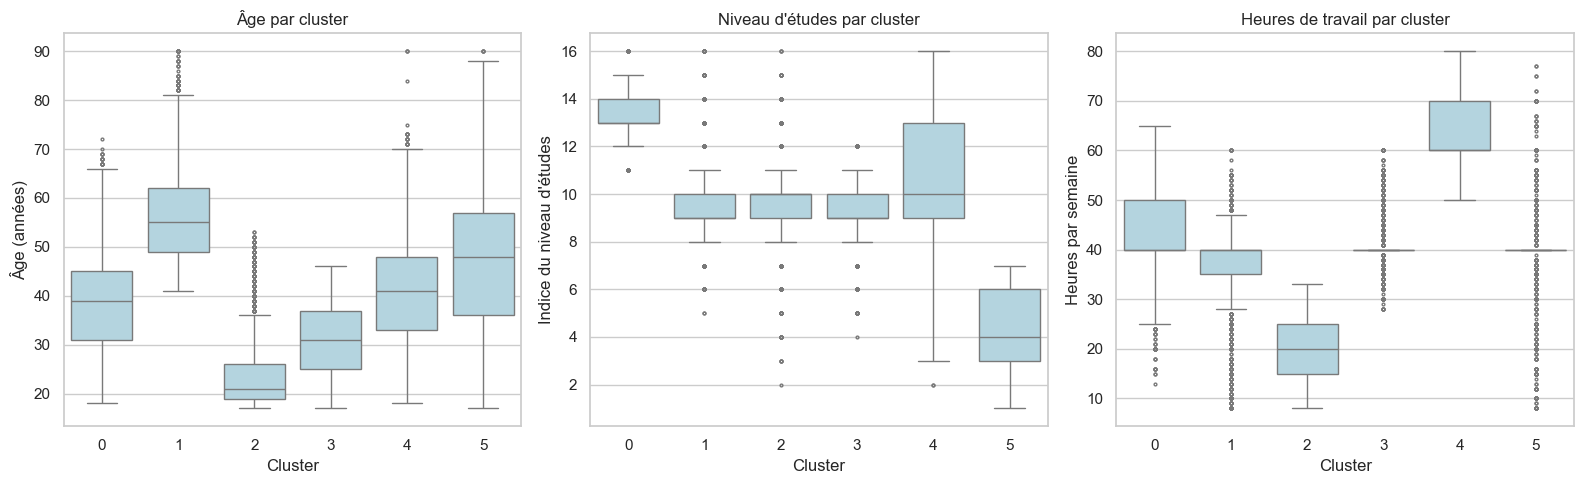

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titres_seg = [
    "Âge par cluster",
    "Niveau d'études par cluster",
    "Heures de travail par cluster"
]

labels_seg = [
    "Âge (années)",
    "Indice du niveau d'études",
    "Heures par semaine"
]

for ax, variable, titre, label in zip(
    axes, variables_seg, titres_seg, labels_seg
):
    sns.boxplot(
        data=data_seg,
        x="cluster",
        y=variable,
        order=range(k_retenu),
        color="lightblue",
        fliersize=2,
        ax=ax
    )

    ax.set_title(titre)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### Visualisation des profils

Nous utilisons des boîtes à moustaches pour comparer la répartition
des valeurs dans chaque groupe, et pas seulement les moyennes.

Les graphiques confirment les profils : cluster 1 plus âgé,
cluster 2 plus jeune avec moins d'heures de travail, cluster 0
avec un niveau d'études élevé, et cluster 4 avec davantage
d'heures de travail. Le cluster 5 présente un niveau d'études faible.

Les distributions se chevauchent : les groupes ne sont pas
parfaitement séparés et leurs membres ne sont pas tous identiques.

### 5.7 - Analyse du revenu par cluster

In [60]:
# Harmonisation locale pour décrire les revenus des groupes.
# La colonne income et les tableaux d'origine restent inchangés.
revenu_seg = (
    data_seg["income"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
)

if not revenu_seg.isin(["<=50K", ">50K"]).all():
    raise ValueError("Certaines valeurs de revenu ne sont pas reconnues.")

analyse_revenu_seg = data_seg[["cluster"]].copy()
analyse_revenu_seg["revenu_sup_50k"] = revenu_seg.eq(">50K").astype(int)

revenus_clusters = (
    analyse_revenu_seg.groupby("cluster")
    .agg(
        Effectif=("revenu_sup_50k", "size"),
        Part_sup_50k=("revenu_sup_50k", "mean")
    )
)

revenus_clusters["Part_sup_50k_pct"] = (
    revenus_clusters.pop("Part_sup_50k") * 100
)

display(revenus_clusters.round(2))

,Effectif,Part_sup_50k_pct
cluster,,
0,10676,46.67
1,9137,27.76
2,4963,2.94
3,16390,12.71
4,4382,39.02
5,3265,6.95


### Revenu et profils des clusters

Nous examinons le revenu après la segmentation pour enrichir
la description des groupes, sans l'utiliser pour les construire.

La proportion de revenus >50K est la plus élevée dans le cluster 0
(46,67 %), caractérisé par un niveau d'études élevé, puis dans
le cluster 4 (39,02 %), caractérisé par davantage d'heures de travail.
Elle est la plus faible dans le cluster 2 (2,94 %), plus jeune
et travaillant moins d'heures.

Ces différences sont des associations observées, pas des preuves
que les études ou les heures de travail causent un revenu élevé.

# 6. Classification

Nous cherchons à prédire si une personne gagne <=50K ou >50K.
La variable cible est income.

### 6.1 - Préparation de la cible

In [61]:
# Cible distincte : les tableaux existants restent inchangés.
revenu_ml = (
    data_ml["income"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
)

y_ml = revenu_ml.map({
    "<=50K": 0,
    ">50K": 1
})

if y_ml.isna().any():
    raise ValueError("Certaines valeurs de la cible ne sont pas reconnues.")

y_ml = y_ml.astype(int)

repartition_cible = pd.DataFrame({
    "Effectif": y_ml.value_counts().sort_index(),
    "Pourcentage": (
        y_ml.value_counts(normalize=True).sort_index() * 100
    )
})

repartition_cible.index = ["<=50K (0)", ">50K (1)"]

display(repartition_cible.round(2))

,Effectif,Pourcentage
<=50K (0),37128,76.06
>50K (1),11685,23.94


Nous avons harmonisé les écritures du revenu et encodé la cible :
0 pour <=50K et 1 pour >50K.

La classe <=50K représente 76,06 % des observations.
Prédire toujours cette classe donnerait déjà 76,06 % d'accuracy
sur ce tableau. Nous ne nous limiterons donc pas à l'accuracy :
nous examinerons aussi le rappel, le F1 et la ROC-AUC.

### 6.2 - Séparation entraînement et test


In [62]:
# Variables explicatives : sans la cible et sans les clusters.
X_ml = data_ml.drop(columns=["income"]).copy()

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml,
    y_ml,
    test_size=0.20,
    stratify=y_ml,
    random_state=42
)

print("Dimensions entraînement :", X_train_ml.shape)
print("Dimensions test :", X_test_ml.shape)

repartition_split = pd.DataFrame({
    "Entraînement (%)": (
        y_train_ml.value_counts(normalize=True).sort_index() * 100
    ),
    "Test (%)": (
        y_test_ml.value_counts(normalize=True).sort_index() * 100
    )
})

repartition_split.index = ["<=50K (0)", ">50K (1)"]

display(repartition_split.round(2))

Dimensions entraînement : (39050, 15)
Dimensions test : (9763, 15)


,Entraînement (%),Test (%)
<=50K (0),76.06,76.06
>50K (1),23.94,23.94


Nous réservons 80 % des observations à l'entraînement et 20 % au test.
La stratification conserve les proportions des deux classes :
76,06 % de <=50K et 23,94 % de >50K dans chaque ensemble.

Le test sera utilisé seulement pour l'évaluation finale.
Les modèles seront comparés sur les données d'entraînement.

### 6.3 - Préparation des variables

In [63]:
numeriques_ml = X_train_ml.select_dtypes(
    include="number"
).columns.tolist()

categorielles_ml = [
    colonne
    for colonne in X_train_ml.columns
    if colonne not in numeriques_ml
]

# Préparation déterministe des catégories, sans toucher à df_clean.
for tableau in [X_train_ml, X_test_ml]:
    for colonne in categorielles_ml:
        tableau[colonne] = (
            tableau[colonne]
            .astype("string")
            .str.strip()
            .fillna("Unknown")
            .replace({"?": "Unknown", "": "Unknown"})
            .astype(str)
        )

# Définition des transformations : aucun apprentissage à ce stade.
preparation_ml = ColumnTransformer([
    (
        "numeriques",
        StandardScaler(),
        numeriques_ml
    ),
    (
        "categories",
        OneHotEncoder(handle_unknown="ignore"),
        categorielles_ml
    )
])

print("Variables numériques :", numeriques_ml)
print("Variables catégorielles :", categorielles_ml)

print("\nNombre de variables numériques :", len(numeriques_ml))
print("Nombre de variables catégorielles :", len(categorielles_ml))

print("\nCatégories Unknown dans l'entraînement :")
for colonne in categorielles_ml:
    nombre = X_train_ml[colonne].eq("Unknown").sum()
    if nombre > 0:
        print(f"{colonne} : {nombre}")

print("\nPréparation définie, mais pas encore ajustée.")

Variables numériques : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net', 'is_married']
Variables catégorielles : ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket']

Nombre de variables numériques : 7
Nombre de variables catégorielles : 8

Catégories Unknown dans l'entraînement :
workclass : 2217
occupation : 2225
native-country : 689

Préparation définie, mais pas encore ajustée.


Nous distinguons les 7 variables numériques des 8 variables catégorielles
pour leur appliquer des traitements adaptés.

Les valeurs inconnues sont conservées sous la catégorie Unknown :
2 217 dans workclass, 2 225 dans occupation et 689 dans native-country
pour l'entraînement.

La standardisation et l'encodage sont définis, mais pas encore appris.
Ils seront ajustés dans chaque pli de validation croisée.

### 6.4 - Comparaison des modèles

Nous comparons une régression logistique, un arbre de décision
et une référence prédisant toujours la classe majoritaire.

Nous utilisons une validation croisée stratifiée à 5 plis,
uniquement sur l'entraînement. Le critère principal de sélection
est le F1 de la classe >50K.

In [64]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

modeles_ml = {
    "Référence majoritaire": DummyClassifier(
        strategy="most_frequent"
    ),
    "Régression logistique": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "Arbre de décision": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    )
}

cv_ml = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metriques_ml = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

pipelines_ml = {}
resultats_cv_ml = []

for nom, modele in modeles_ml.items():
    print("Évaluation :", nom, flush=True)

    pipeline = Pipeline([
        ("preparation", clone(preparation_ml)),
        ("modele", modele)
    ])

    pipelines_ml[nom] = pipeline

    scores = cross_validate(
        pipeline,
        X_train_ml,
        y_train_ml,
        cv=cv_ml,
        scoring=metriques_ml,
        n_jobs=1,
        error_score="raise"
    )

    resultats_cv_ml.append({
        "Modèle": nom,
        "Accuracy CV": scores["test_accuracy"].mean(),
        "Precision CV": scores["test_precision"].mean(),
        "Recall CV": scores["test_recall"].mean(),
        "F1 CV": scores["test_f1"].mean(),
        "Écart-type F1": scores["test_f1"].std(),
        "ROC-AUC CV": scores["test_roc_auc"].mean()
    })

tableau_cv_ml = (
    pd.DataFrame(resultats_cv_ml)
    .set_index("Modèle")
    .sort_values("F1 CV", ascending=False)
)

display(tableau_cv_ml.round(4))

Évaluation : Référence majoritaire
Évaluation : Régression logistique
Évaluation : Arbre de décision


,Accuracy CV,Precision CV,Recall CV,F1 CV,Écart-type F1,ROC-AUC CV
Modèle,,,,,,
Régression logistique,0.8550,0.7373,0.6125,0.6691,0.0052,0.9096
Arbre de décision,0.8585,0.7750,0.5769,0.6613,0.0105,0.9062
Référence majoritaire,0.7606,0.0000,0.0000,0.0000,0.0000,0.5000


Nous comparons les modèles par validation croisée pour choisir
sans utiliser le test final.

La régression logistique obtient le meilleur F1 moyen (0,6691),
contre 0,6613 pour l'arbre. Elle retrouve davantage de revenus >50K :
rappel de 61,25 % contre 57,69 %.

L'arbre a une accuracy et une precision légèrement supérieures,
mais notre critère principal est le F1. Nous retenons donc
la régression logistique, tout en notant que l'écart est faible.

La référence atteint 76,06 % d'accuracy mais ne détecte aucun >50K,
ce qui confirme l'intérêt de ne pas utiliser l'accuracy seule.

# 7. Évaluation et interprétation des résultats

## 7.1 - Évaluation du modèle retenu sur le test

In [65]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    classification_report
)

# Sélection selon le F1 moyen en validation croisée.
nom_retenu_ml = tableau_cv_ml["F1 CV"].idxmax()

# Nouveau pipeline entraîné sur tout l'ensemble d'entraînement.
modele_final_ml = clone(pipelines_ml[nom_retenu_ml])
modele_final_ml.fit(X_train_ml, y_train_ml)

pred_ml = modele_final_ml.predict(X_test_ml)
proba_ml = modele_final_ml.predict_proba(X_test_ml)[:, 1]

scores_test_ml = pd.DataFrame([{
    "Modèle": nom_retenu_ml,
    "Accuracy": accuracy_score(y_test_ml, pred_ml),
    "Balanced accuracy": balanced_accuracy_score(y_test_ml, pred_ml),
    "Precision >50K": precision_score(
        y_test_ml, pred_ml, zero_division=0
    ),
    "Recall >50K": recall_score(
        y_test_ml, pred_ml, zero_division=0
    ),
    "F1 >50K": f1_score(
        y_test_ml, pred_ml, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test_ml, proba_ml)
}])

display(scores_test_ml.round(4))

print("\nRapport par classe :")
print(classification_report(
    y_test_ml,
    pred_ml,
    labels=[0, 1],
    target_names=["<=50K", ">50K"],
    digits=4,
    zero_division=0
))

,Modèle,Accuracy,Balanced accuracy,Precision >50K,Recall >50K,F1 >50K,ROC-AUC
0,Régression logistique,0.8565,0.7734,0.742,0.614,0.672,0.9104



Rapport par classe :
              precision    recall  f1-score   support

       <=50K     0.8848    0.9328    0.9082      7426
        >50K     0.7420    0.6140    0.6720      2337

    accuracy                         0.8565      9763
   macro avg     0.8134    0.7734    0.7901      9763
weighted avg     0.8506    0.8565    0.8516      9763



Nous évaluons le modèle retenu sur les 9 763 observations du test,
qui n'ont pas servi à choisir le modèle.

La régression logistique obtient 85,65 % d'accuracy, un F1 de 0,6720
pour >50K et une ROC-AUC de 0,9104. Ces résultats sont proches
de ceux obtenus en validation croisée.

Parmi les personnes prédites >50K, 74,20 % appartiennent réellement
à cette classe. Le modèle retrouve cependant seulement 61,40 %
des revenus réellement >50K, contre 93,28 % des revenus <=50K.
La détection de la classe minoritaire reste donc une limite.

## 7.2 - Analyse des erreurs : matrice de confusion

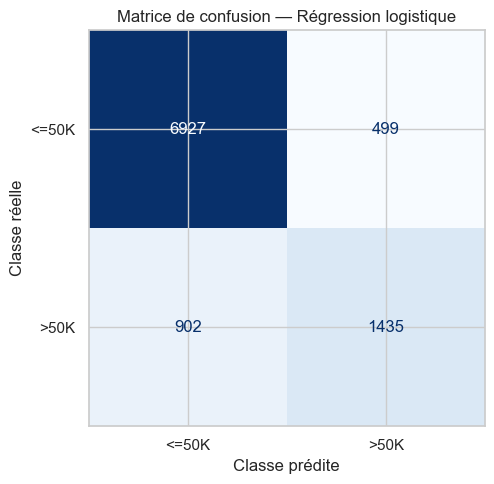

Matrice :
[[6927  499]
 [ 902 1435]]


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice_ml = confusion_matrix(
    y_test_ml,
    pred_ml,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matrice_ml,
    display_labels=["<=50K", ">50K"]
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Matrice de confusion — Régression logistique")
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")

plt.tight_layout()
plt.show()

print("Matrice :")
print(matrice_ml)

Nous utilisons la matrice de confusion pour identifier les erreurs
que l'accuracy globale ne détaille pas.

Le modèle classe correctement 6 927 observations <=50K et 1 435 >50K.
Il confond 499 revenus <=50K avec >50K, et manque 902 revenus >50K.

La principale limite est donc la détection incomplète des revenus >50K :
38,60 % des observations de cette classe sont classées <=50K.

## 7.3 - Courbe ROC

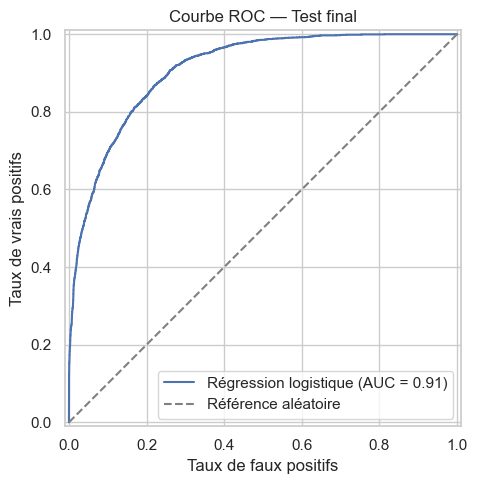

In [67]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test_ml,
    proba_ml,
    name="Régression logistique",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Référence aléatoire"
)

ax.set_title("Courbe ROC — Test final")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

Nous traçons la courbe ROC pour examiner la distinction entre les
classes lorsque le seuil de décision varie.

La courbe est nettement au-dessus de la référence aléatoire,
avec une AUC de 0,9104. Le modèle possède donc une bonne capacité
de discrimination.

Cette AUC ne signifie pas que 91,04 % des prédictions sont correctes :
l'accuracy est de 85,65 %, et le rappel de >50K reste de 61,40 %.

## 7.4 - Bilan et limites

La segmentation fournit six profils interprétables selon l'âge,
le niveau d'études et les heures de travail. La silhouette estimée
de 0,3391 est la meilleure parmi les solutions testées de 2 à 6 groupes,
mais les distributions se chevauchent.

La régression logistique est retenue selon le F1 en validation croisée.
Sur le test, elle atteint 85,65 % d'accuracy et un F1 de 0,6720
pour >50K. Sa principale limite est le rappel de cette classe :
902 revenus >50K ne sont pas détectés.

L'évaluation reprend les transformations réalisées précédemment
par le groupe. Certaines, comme les bornes de winsorisation,
ont été calculées avant la séparation entraînement/test.
Les scores doivent être interprétés avec cette limite.

Les variables sexe et race sont utilisées, mais l'équité des
performances entre sous-groupes n'a pas été évaluée.

Les résultats décrivent des profils et des associations prédictives,
pas des relations causales.

# 8. Fichier final : données nettoyées et préparées
Export du jeu de données après l'ensemble des transformations (doublons exacts supprimés, `education` et `fnlwgt` retirées, `hours-per-week` winsorisée, variables `capital_net`, `is_married` et `age_bucket` ajoutées, cible harmonisée et encodée 0 = <=50K / 1 = >50K). La modalité `?` est conservée comme catégorie.

In [68]:
import os
os.makedirs("output", exist_ok=True)

df_final = df_clean.copy()
df_final["income"] = (
    df_final["income"].astype(str).str.strip().str.rstrip(".")
    .map({"<=50K": 0, ">50K": 1})
)
assert df_final["income"].notna().all()

df_final.to_csv("output/adult_clean_prepared.csv", index=False)
print("Fichier exporté :", df_final.shape)
print(df_final["income"].value_counts(normalize=True).round(4))

Fichier exporté : (48813, 16)
income
0    0.7606
1    0.2394
Name: proportion, dtype: float64
